In [1]:
library(DBI)
library(RPostgres)
library(tidyverse)
library(glue)
library(httr)
library(jsonlite)
library(dplyr)
library(tidyr)
library(lubridate)
library(stringr)
library(ggplot2)
library(readr)

source("pitcher_profile_functions.r")
source("data_extract_functions.r")


pitcher_id <- 669373
pitcher_scouting_report_df <- pull_pitcher_scouting_report_from_database(pitcher_id)

# grab specific pitch type >= 10% usage

pitcher_pitch_arsenal <- create_pitcher_pitch_arsenal(pitcher_scouting_report_df)

pitcher_statcast_df <- pull_pitcher_statcast_data_from_csv(pitcher_id, pitcher_pitch_arsenal)

pitcher_pitch_usage_df <- create_pitcher_pitch_usage_df(pitcher_statcast_df)

pitcher_pitch_characteristics_df <- create_pitcher_pitch_characteristics_df(pitcher_statcast_df)

pitcher_pitch_performance_df <- create_pitcher_pitch_performance_df(pitcher_statcast_df)

########### plots #####################

pitch_visual_plots <- create_pitcher_pitch_visual_plots(pitcher_statcast_df)

pitch_usage_plots <- create_pitcher_usage_plots(pitcher_pitch_usage_df)

pitch_characteristics_plots <- create_pitch_characteristics_plots(pitcher_pitch_characteristics_df)

pitch_tendencies_plots <- create_pitch_tendency_plots(pitcher_scouting_report_df)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'jsonlite'


The following object is masked from 'package:purrr':

    flatten


New names:
• `` -> `...1`


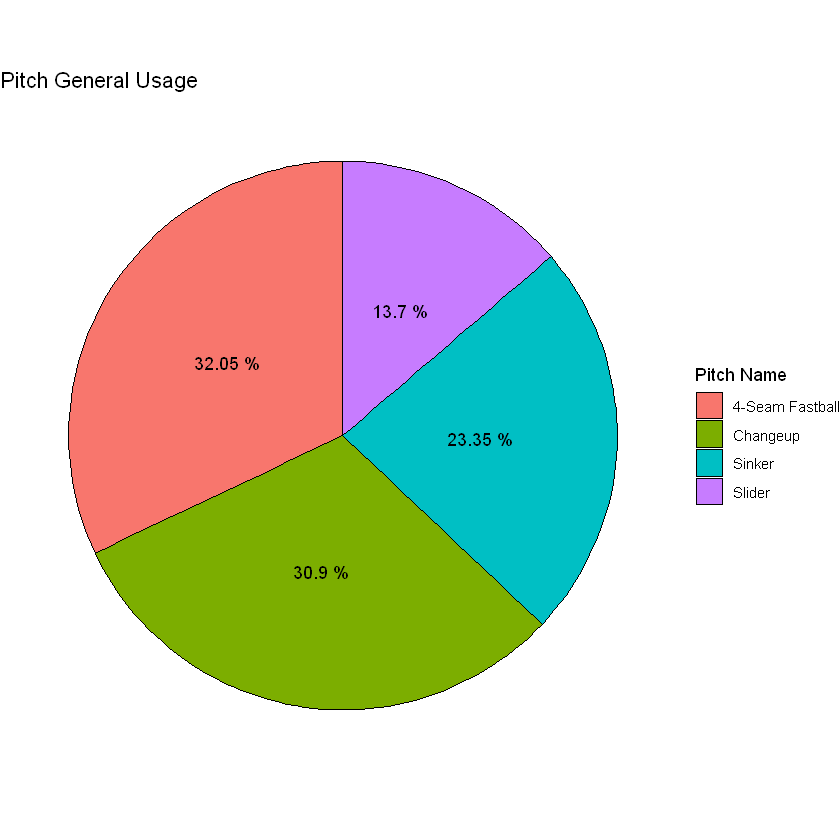

[[1]]

[[2]]

[[3]]


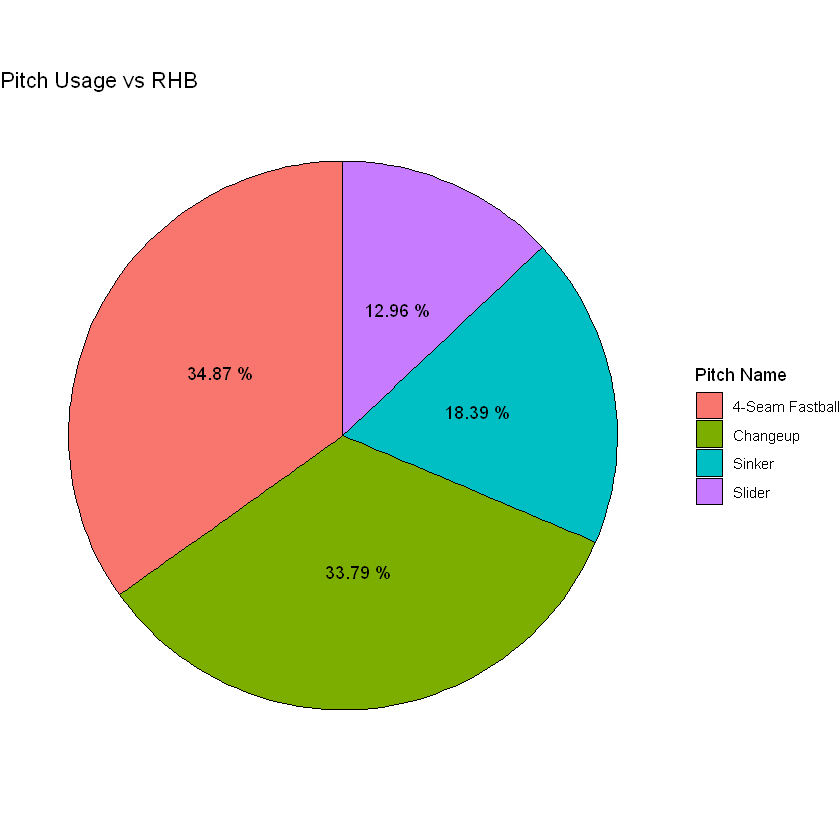

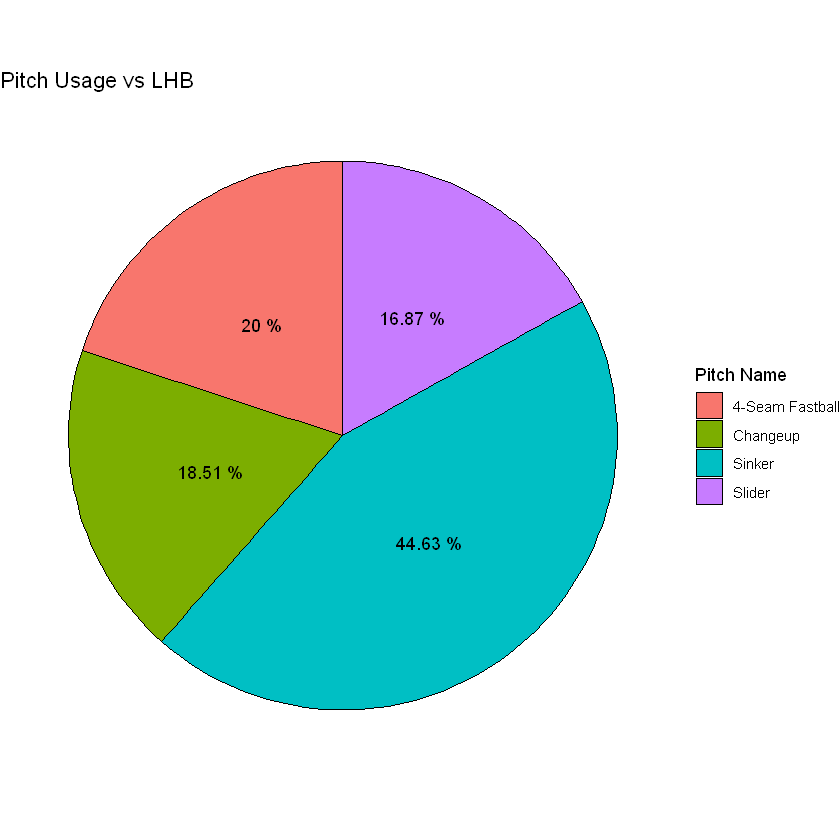

In [97]:
source("pitcher_profile_functions.r")
source("data_extract_functions.r")

pitch_usage_plots <- create_pitcher_usage_plots(pitcher_pitch_usage_df) 

pitch_usage_plots




pitch_type,pitch_usage,pitch_name,avg_velo,avg_spin
<chr>,<dbl>,<chr>,<dbl>,<dbl>
CH,30.90,Changeup,87.97,1834.755
FF,32.05,4-Seam Fastball,97.54,2356.345
SI,23.35,Sinker,97.30,2248.622
SL,13.70,Slider,90.11,2240.862


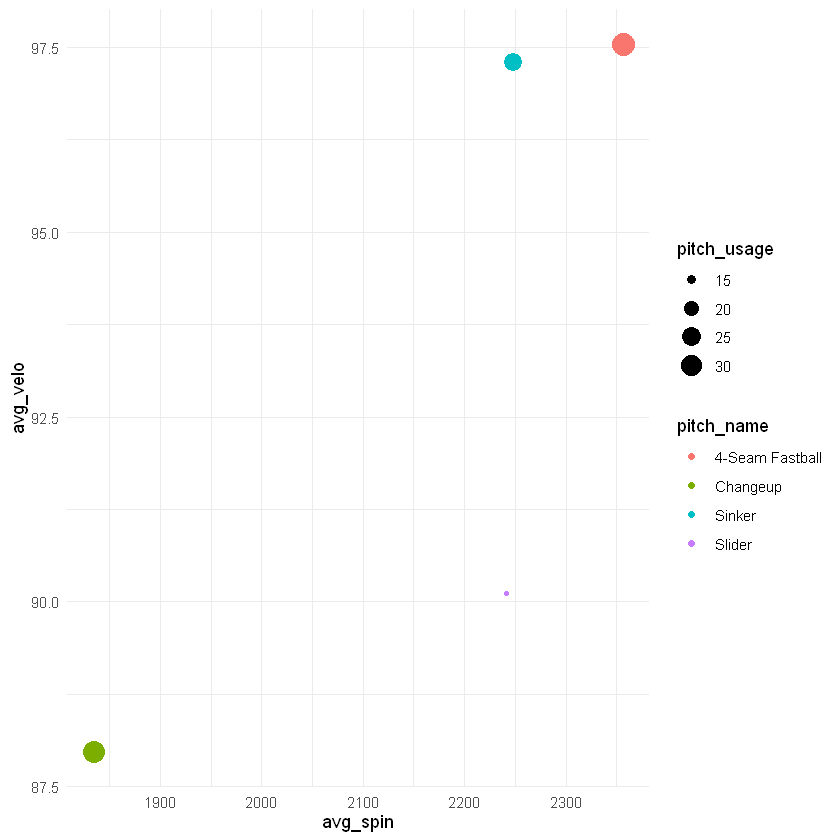

In [46]:
pitch_general_characteristics_df_for_plot




library(tidyr)
library(ggplot2)
library(dplyr)

ggplot(pitch_general_characteristics_df_for_plot,
       aes(x = avg_spin,
           y = avg_velo,
           size = pitch_usage,
           color = pitch_name)) +
  geom_point() +
  theme_minimal()

